In [1]:
import numpy as np
import random as rnd
import pandas as pd
import string as strs
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi
#scipy chi
from scipy.stats import chi,chi2_contingency,chi2


import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Pkg import Date Time
import time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd

import csv

# Graph Plot Packg
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

###################################################
'''State-models'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices
from statsmodels.stats.outliers_influence import OLSInfluence
###################################################
'''sciket-learn'''
###################################################
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
from zlib import crc32
import hashlib

###################################################
'''scikit-lern Data Set'''
###################################################
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import load_iris

###################################################
'''Tenser flow packeges'''
###################################################
#import tensorflow as tf
#from tensorflow import keras

###################################################
'''Miscellaneous'''
###################################################
import tarfile
import urllib.request

import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors

Polynomial just provide transformations on Data set. It not provides any kind of regressions.
It's taken mainaly 3 arguments

- PolynomialFeatures(
   - degree=2, # just provide degree of regressors
   - interaction_only=False, 
   - include_bias=True, 
   - order='C' # Not includes
                    )

1. include_bias = True it will add const ter terms in data set just like sm.add_constant()
2. interaction_only = True

   let regressors = [u v]

   and degree = 2

   if interaction_only = False; (Include higher degree terms)   
      - include_bias = True

   Const + u + v + u^2 + uv + v^2 (with degree = 2)

   Const + u + v + u^2 + uv + v^2 + u^3 + u^2v + uv^2 + v^3 (with degree = 3)

   if interaction_only = True  (ingnore higher degree terms); 
      - include_bias     = False ()

   u + v + uv  (with degree = 2)

   u + v + uv  (with degree = 3)
   
   u + v + uv  (with degree = 4)  [Regressions eqtions are all same, no effect]

#### Api with default value:

sklearn.preprocessing.PolynomialFeatures(
   - degree=2, *, interaction_only=False, include_bias=True, order='C'
   )



## Polynomial Regression

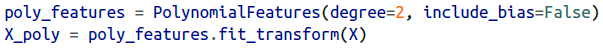

X_poly now contains the original feature of X plus 
the square of this feature. Now you can fit a LinearRegression 
model to this extended training data.

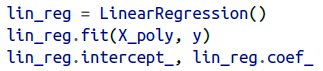

PolynomialFeatures also adds all combinations of 
features up to the given degree. For example, if 
there were two features a and b, PolynomialFeatures 
with degree=3 would not only add the features a^2, 
a^3, b^2, and b^3, but also the combinations ab, 
a^2b, and ab^2.

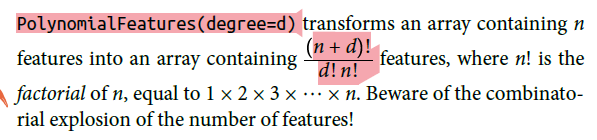

### Learning Curves:
Qus How come in picture?

Figure 4-14 applies
a 300-degree polynomial model to the preceding training data, and compares the
result with a pure linear model and a quadratic model (2nd-degree polynomial).

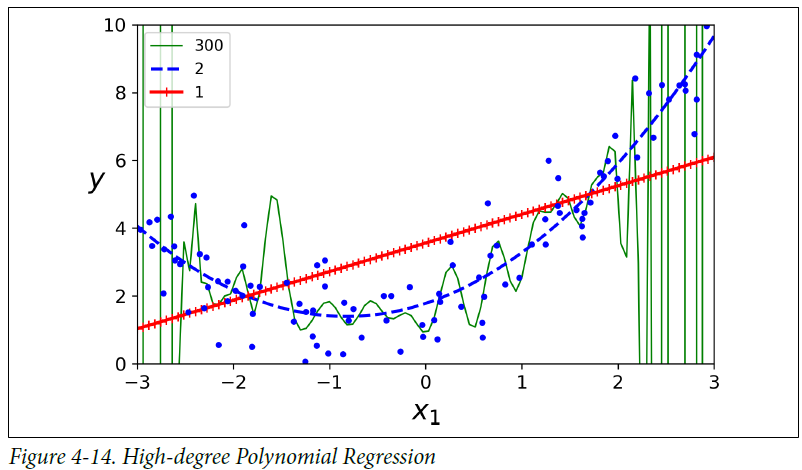

#### Qus: Problem with higher degree polynomial?

high-degree Polynomial Regression model is severely overfitting the
training data, while the linear model is underfitting it.

#### Qus: How to avoide overfitting & underfitting ?

cross-validation to get an estimate of a model’s generalization
performance. If a model performs well on the training data but generalizes poorly
according to the cross-validation metrics, then your model is overfitting. If it performs
poorly on both, then it is underfitting.



In [5]:
# Create Dataset
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1) # based on a simple quadratic equation

In [6]:
# PolynomialFeatures with degree of 2
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# X_poly now contains the original feature of X plus the square of this feature.
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.98108539]), array([[1.03500101, 0.50485867]]))

In [22]:
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)    
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")

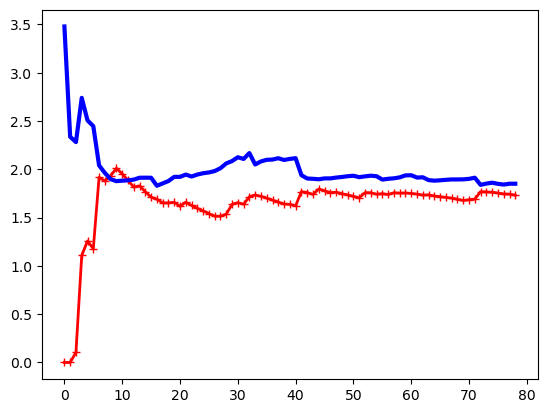

In [25]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

### Learnig curve & Pipeline by Exixting API
#### Prepare Pipeline
Pipeline -> Polynomial + Linear regressions

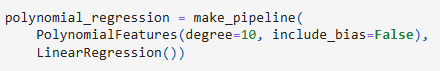

#### Apply pipeline to Learning curve

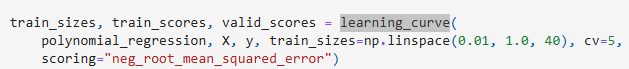

Need to understand
sklearn.model_selection.learning_curve(estimator, # object type that implements the “fit” method
                                       X, y, *, # X,y 2D array
                                       groups=None, 
                                       train_sizes=array([0.1, 0.33, 0.55, 0.78, 1.]), # ???
                                       cv=None, 
                                       scoring=None,
                                       args ....)

#### Plot Learning Curve

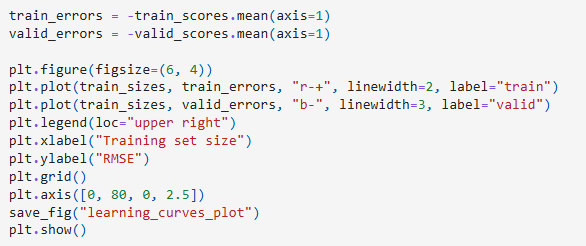

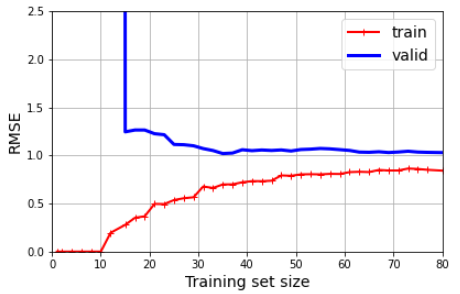